In [3]:
import os
os.chdir("/content")
!rm -rf STAT-7220- Applied-Experimental-Design
print(os.getcwd())

/content


In [4]:
import os
os.chdir("/content")
!rm -rf STAT-7220- Applied-Experimental-Design


# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "djuarez7-KSU"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
   print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

**Answer:**

The main obkective of the study is determined the combination of ingredients (Protein, Salsa & Potatoes) that maximize the satisfaction rate of the consumers, while we minimize the ingredints waste and cost.

2. State the outcome variable and how it was measured.

**Answer:**

The DV is the *Satisfaction Rate* and and it will be measure on a scale from 1 to 10 being 1 equal to terrible and 10 equal to amazing. Where each  of the residents will assigned to the burritos after they eat it.

3. State the main effects. What lurking variables may be present?

Main Effects:

  - Protein (Bacon, Sausage, Chorizo)
  - Salsa (Mild, Hot)
  - Potatoes (Yes, No)

Lurking Variables:

  - Hungry levels
  - Personal Preferences
  - Time of the test
  - Age
  - Nutritional habits

4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?

Since they will be just 12 ingredients combinations (3 x 2 x 2) by 5 replications equal to 60 burritos and participants, this amount of burritosn doesn't represent a big cost impact for this reason a full factorial study desing is feasible.

The full factorial design also will allow to estimate the main effect of all the interaction effects without aliasing.

With a $2^k$ fractional design we have the risk of confounding  the effects and will matbe missed important interactions.

5. State all sets of statistical hypotheses.

- For our main effects:

Protein:

$$ H_{01}: \alpha_{\text{Bacon}} = \alpha_{\text{Sausage}} = \alpha_{\text{Chorizo}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

Salsa:

$$ H_{02}: \beta_{\text{mild}} = \beta_{\text{hot}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

Potatoes:

$$ H_{03}: \gamma_{\text{yes}} = \gamma_{\text{no}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$

- For our two-way interactions:

$$ H_{04}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j $$
$$ H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0 $$

$$ H_{05}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k $$
$$ H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0 $$

$$ H_{06}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k $$
$$ H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0 $$

- For our three-way interaction:

$$ H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k $$
$$ H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq 0 $$

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

**Answer:**

The first explanatory analysis support all the **Alternative Hypotheses**, since all the interactions at one-way, two-way and three-way levelas appears to have different means numerically and also graphically.

In [7]:
## Question 6 Code ##
## Import pandas library ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import Football Helmet.xlsx File ##

burritos = pd.read_excel("Busters Burritos.xlsx")

## Data Integrity Check ##

print(burritos.info())

## Calculate Means & SDs of Shell Type #
protein_stats = burritos.groupby("Protein")['Satisfaction'].agg(['mean','std'])
salsa_stats = burritos.groupby("Salsa")['Satisfaction'].agg(['mean','std'])
potatoes_stats = burritos.groupby("Potatoes")['Satisfaction'].agg(['mean','std'])

print(protein_stats)
print(salsa_stats)
print(potatoes_stats)


## Protein x Salsa ##

protein_salsa_stats = burritos.groupby(["Protein", "Salsa"])["Satisfaction"].agg(['mean', 'std'])

print(protein_salsa_stats)

## Protein x Potatoes ##

protein_potatoes_stats = burritos.groupby(["Protein", "Potatoes"])["Satisfaction"].agg(['mean', 'std'])

print(protein_potatoes_stats)

## Salsa x Potatoes ##

salsa_potatoes_stats = burritos.groupby(["Salsa", "Potatoes"])["Satisfaction"].agg(['mean', 'std'])

print(salsa_potatoes_stats)


## Protein x Salsa x Potatoes ##

protein_salsa_potatoes_stats = burritos.groupby(["Protein", "Salsa", "Potatoes"])["Satisfaction"].agg(['mean', 'std'])

print(protein_salsa_potatoes_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       60 non-null     object 
 1   Salsa         60 non-null     object 
 2   Potatoes      60 non-null     object 
 3   Satisfaction  60 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.0+ KB
None
         mean       std
Protein                
Bacon    6.49  1.046749
Chorizo  6.74  1.106155
Sausage  5.82  1.058599
           mean       std
Salsa                    
Hot    6.073333  1.240393
Mild   6.626667  0.932159
          mean       std
Potatoes                
No        6.11  1.075864
Yes       6.59  1.135432
               mean       std
Protein Salsa                
Bacon   Hot    6.16  0.981156
        Mild   6.82  1.052827
Chorizo Hot    6.58  1.482340
        Mild   6.90  0.573488
Sausage Hot    5.48  1.054935
        Mild   6.16  0.997998
                  m

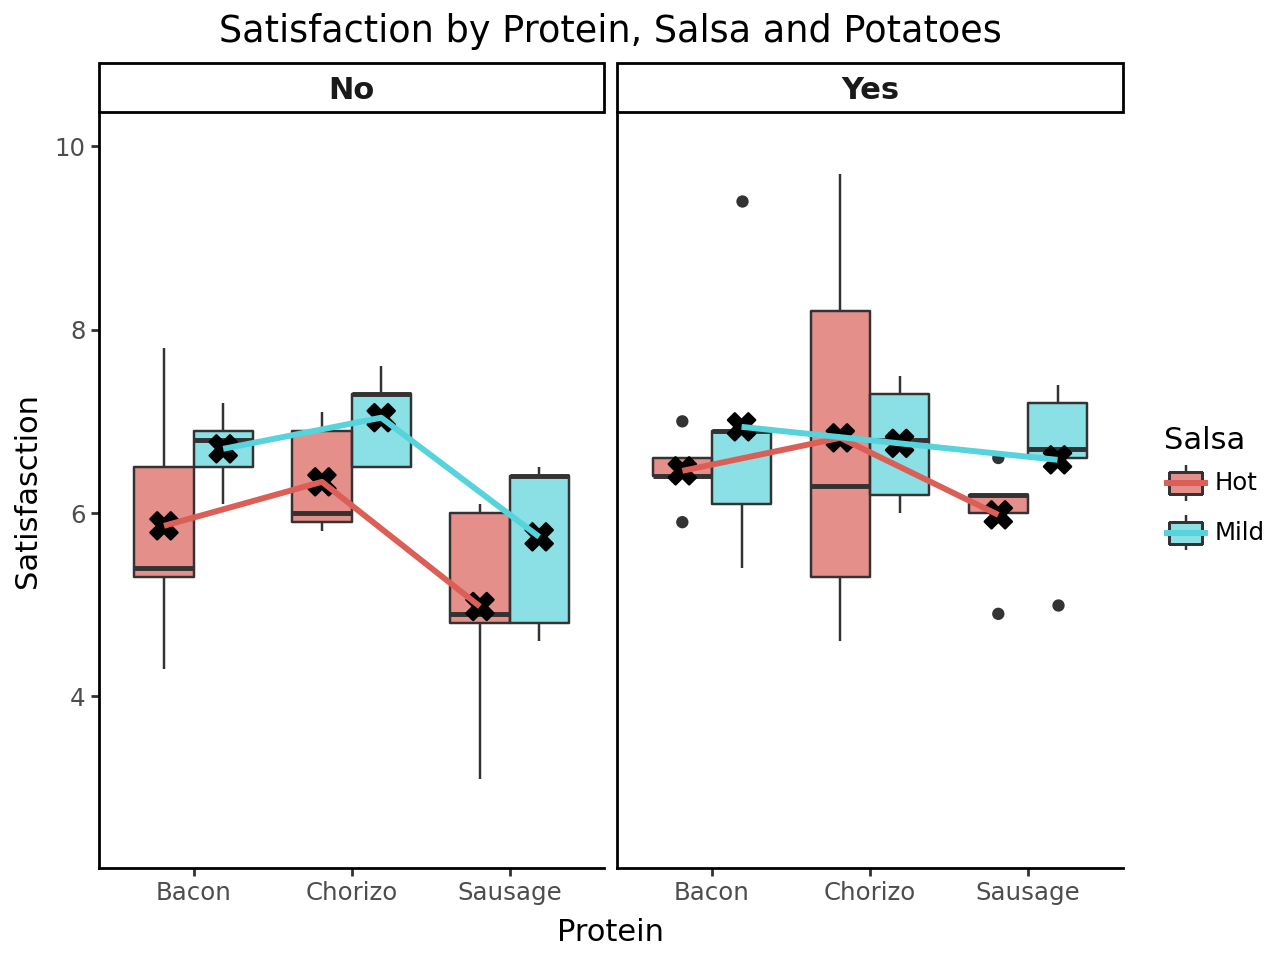

In [8]:
## Install plotnine
#%pip install plotnine
## Import all plotnine functions ##:
from plotnine import *

# Prepare summarized data
burritos_means = protein_salsa_potatoes_stats.reset_index()[["Protein", "Salsa", "Potatoes", "mean"]]

# Define dodge position for aligning points/lines with the boxplots
box_dodge = position_dodge(0.75)

# Build a single faceted plot
p = (
    ggplot(burritos, aes(x='Protein', y='Satisfaction')) +

    # 1. Boxplot layer (base visualization)
    geom_boxplot(aes(fill='Salsa'), alpha=0.7, position=box_dodge) +

    # 2. Mean points (using separate summary data)
    geom_point(
        data=burritos_means,
        mapping=aes(y='mean', group='Salsa'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black'
    ) +

    # 3. Mean lines
    geom_line(
        data=burritos_means,
        mapping=aes(y='mean', group='Salsa', color='Salsa'),
        size=1.2,
        position=box_dodge
    ) +

    # 4. Facet by Potatoes (two panels side-by-side)
    facet_wrap('~Potatoes', ncol=2) +

    # 5. Styling and labels
    labs(
        title = "Satisfaction by Protein, Salsa and Potatoes",
        x = "Protein",
        y = "Satisfasction",
        fill = "Salsa",
        color = "Salsa"
    ) +

    theme_classic() +
    theme(
        plot_title = element_text(hjust=0.5),
        strip_text = element_text(size=11, weight='bold')
    ) +

    scale_y_continuous(limits=(2.5, 10))
)

# Display
p

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

**Answer:**

The QQ plot shows that  the majority of the points falled along the diagonal line, just some deviations at the right-tail  but not enought to fail to reject the null hypothesis.

Also the Shapiro-Wilkins test provided a *p-value > 0.05* grather than our threshold of 0.05 we **fail to reject the null hypothesis** of normality, meaning that the normality assumption is met.

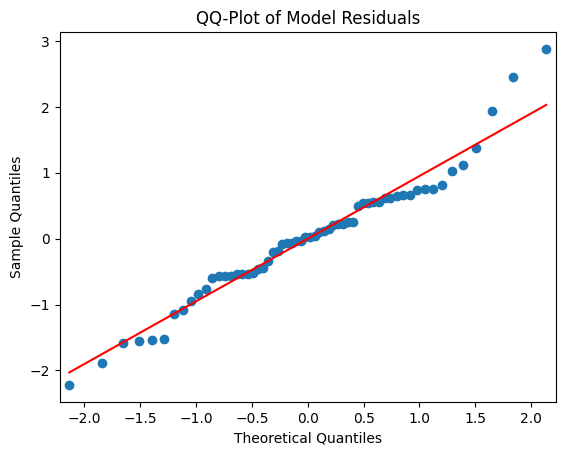

Shapiro-Wilk Test Results:
Statistic: 0.9693192084188245
p-value: 0.13513593912584776


In [9]:
## Question 7 Code ##
## Import Statsmodels ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

## Fit Full Factorial Model ##

model = ols('Satisfaction ~ Protein*Salsa*Potatoes', data=burritos).fit()

## Parse out model residuals ##

residuals = model.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")



8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

**Answer:**

For constant variance:

 - None of our points overpass our threshold of |3|.
 - The points appear randomly scattered around the horizontal line at 0.
 - The Levene's test p-value is greater than 0.05, suggesting that the constant variance assumption is met.
 - **Fail to reject the null hypothesis**

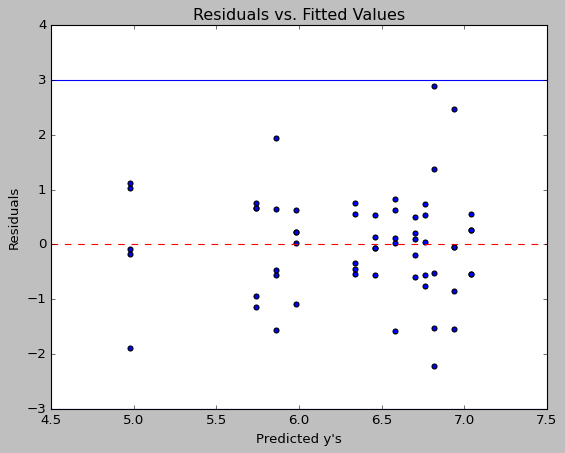

Levene test statistic: 1.3407935463088752
Levene p-value: 0.23217125774654543


In [12]:
## Question 8 Code ##
from scipy.stats import levene
## Test of Homogeneity of Variance ##


## Levene's Test ##
# Levene test across all groups
lev_stat, lev_p = levene(
    *[
        group["Satisfaction"].values
        for name, group in burritos.groupby(["Protein", "Salsa", "Potatoes"])
    ]
)

## Scatterplot of Standardized Residuals vs. Fitted Values ##

## Get Standardized Residuals ##

model_residuals = model.resid

## Get Fitted Values ##

fitted_values = model.fittedvalues

## Scatterplot ##

## Create the plot ##

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, model_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

print("Levene test statistic:", lev_stat)
print("Levene p-value:", lev_p)


9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

**Answer:**

- **Interaction Effects:**
     - The three-way interaction term (Protein x Salsa x Potatoes) was not statistically significant (*F = 0. 1032, p = 0..9021*).

     - The two-way interaction terms were also not statistically significant (all * p > 0.05*).

     

- **Main Effects:**

     - The main effects were also not statistically significant (all * p > 0.05*).


In [19]:
## Question 9 Code ##
anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                            sum_sq    df           F        PR(>F)
Intercept               171.698000   1.0  151.844351  1.774939e-16
Protein                   4.757333   2.0    2.103619  1.331229e-01
Salsa                     1.764000   1.0    1.560027  2.177184e-01
Potatoes                  0.900000   1.0    0.795932  3.767632e-01
Protein:Salsa             0.024667   2.0    0.010907  9.891545e-01
Protein:Potatoes          0.370667   2.0    0.163903  8.492974e-01
Salsa:Potatoes            0.162000   1.0    0.143268  7.067228e-01
Protein:Salsa:Potatoes    0.233333   2.0    0.103176  9.021674e-01
Residual                 54.276000  48.0         NaN           NaN


10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

**Answer:**

Since any of our effects or interaction were statistically significant the Post-Hoc test (like Tukey HSD) is not appropiated and the results of these test shouldn't be interpreted.

From our test, the only thing that we can confirm is that Chorizo and Sausages have a statistical significant adjusted p-value.


In [14]:
## Question 10 Code ##

#Post-hoc tests for protein

import statsmodels.stats.multicomp as mc

tukey = mc.pairwise_tukeyhsd(burritos["Satisfaction"], burritos["Protein"])
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo     0.25 0.7419 -0.5649  1.0649  False
  Bacon Sausage    -0.67 0.1268 -1.4849  0.1449  False
Chorizo Sausage    -0.92 0.0233 -1.7349 -0.1051   True
------------------------------------------------------


11. Calculate and interpret partial $\eta^2$ for the main effects.

**Answer:**

- From the main effects, just  Protein is consider to have larger effect.

- Sala and Potatoes as main effects have medium-small effect.

- The remaining two-way and the three-way interactions have very small effect sizes or even none effect.

In [15]:
## Question 11 Code ##
## Load pingouin ##
!pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(dv='Satisfaction',between=["Protein","Salsa","Potatoes"],data=burritos,effsize="np2").round(4)

print(mod_p[["Source","np2"]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 16.4 MB/s eta 0:00:00
                       Source     np2
0                     Protein  0.1429
1                       Salsa  0.0780
2                    Potatoes  0.0599
3             Protein * Salsa  0.0075
4          Protein * Potatoes  0.0305
5            Salsa * Potatoes  0.0124
6  Protein * Salsa * Potatoes  0.0043
7                    Residual     NaN


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

**Answer:**

Since the ANOVA results didn't find statistically significant evidence around the interaction effects, and the partial partial values just found that Protein has the higher effect. My recommendation is that they should recommend  just based on the protein satisfaction mean, being Chorizo the first option, follow by Bacon and the last recommendation should be Sausage burritos.


## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

**Answer:**

The objective of this study is to determine how the different features (effects) and their interactions impact the burritos sales.

2. Specify the outcome variable and how it is measured.

**Answer:**

The outcome variable is the Sales amount per day.

3. Specify the independent variables. What lurking variables may be present?

**Answer:**

- Location:
  
  a. Brewery
  
  b. University

- Timing:

  a. Weekday

  b. Weekend

- Marketing:

  a. Independent

  b. Partnership

**Possible lurking variables:**

- Other restaurants nearby
- Season (Spring, Summer, Fall or Winter)
- Time (morning, evening, night)
- Weather (raining, cold, hot)

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

**Answer:**

The full $2^k$ factorial design will include all the possible combinations, with the $2^{3-1}$ fractional factorial design will use just a fraction of the full set of combinations.

This will be a good design because will save time and resources to the company and still will estimate the most importan effects.

5. State the sets of null and alternative hypotheses for this experiment.

- For our main effects:

Location (A):

$$ H_{0}: \alpha_{\text{location}} = \alpha_{\text{-location}} $$
$$ H_{1}: \alpha_{\text{location}}\neq \alpha_{\text{-location}}$$

Timing (B):

$$ H_{0}: \beta_{\text{timing}} = \beta_{\text{-timing}}  $$
$$ H_{1}: \beta_{\text{timing}} \neq \beta_{\text{-timing}} $$

Marketing (C):

$$ H_{0}: \mu_{\text{marketing}} = \mu_{\text{-marketing}} $$
$$ H_{1}: \mu_{\text{marketing}} \neq \mu_{\text{-marketing}} $$


6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

**Answer:**

The first explonatory analysis support more empirical evidence of the **alternative hypotheses** since all the means differ from each other at the one-way level.

In [16]:
## Question 6 Code ##
## Import relevant libraries ##
import pandas as pd
import numpy as np

## Read in the Data ##

sales_burritos = pd.read_excel("Busters Burrito Sales.xlsx")

## Evaluate the Data ##

print(sales_burritos.info())
print(sales_burritos.head())

## Add Effect Column to buster dataframe ##

sales_burritos['Effect'] = np.repeat(["c","b","a","abc"],repeats=4)

print(sales_burritos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   16 non-null     object 
 1   Timing     16 non-null     object 
 2   Marketing  16 non-null     object 
 3   Sales      16 non-null     float64
dtypes: float64(1), object(3)
memory usage: 644.0+ bytes
None
     Location   Timing    Marketing    Sales
0     Brewery  Weekday  Independent   767.87
1     Brewery  Weekday  Independent   875.14
2  University  Weekday  Independent   865.84
3  University  Weekday  Independent   544.24
4     Brewery  Weekend  Independent  1055.34
     Location   Timing    Marketing    Sales Effect
0     Brewery  Weekday  Independent   767.87      c
1     Brewery  Weekday  Independent   875.14      c
2  University  Weekday  Independent   865.84      c
3  University  Weekday  Independent   544.24      c
4     Brewery  Weekend  Independent  1055.34      b


     Location      mean         std
0     Brewery  1108.675  224.129011
1  University   991.610  254.431780
    Timing        mean         std
0  Weekday   878.39625  173.385636
1  Weekend  1221.88875  159.111741
     Marketing        mean         std
0  Independent   927.15875  211.210644
1  Partnership  1173.12625  208.851508


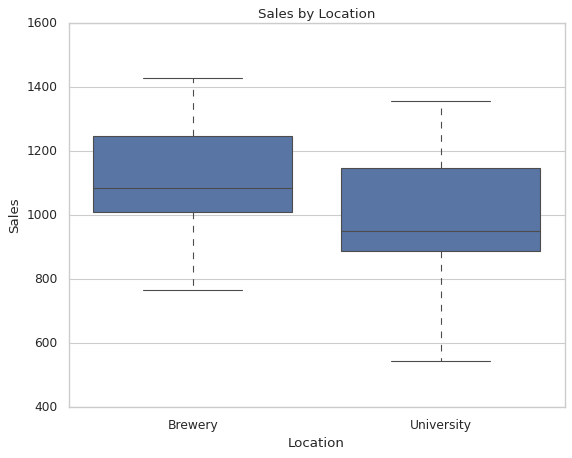

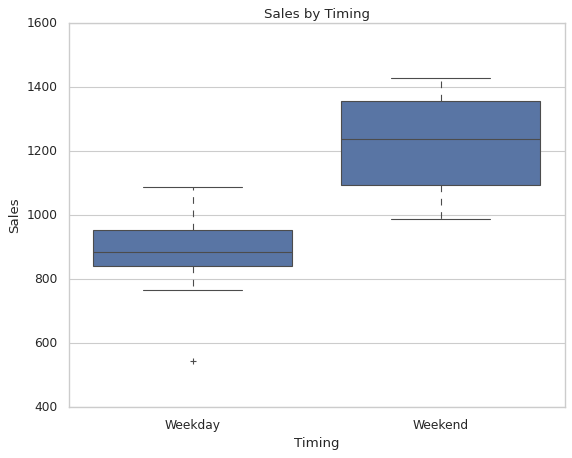

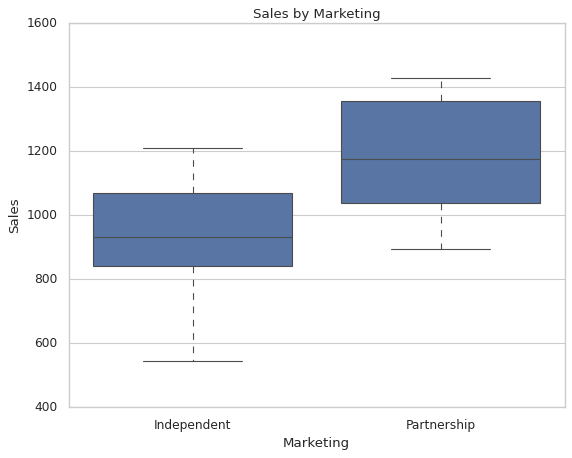

In [21]:
## Calculate Summary Statistics for the Main Effects ##

import seaborn as sns
import matplotlib.pyplot as plt

## Location Effect ##

location_effect = sales_burritos.groupby('Location')['Sales'].agg(['mean','std']).reset_index()

print(location_effect)

## Timing Effect ##

timing_effect = sales_burritos.groupby('Timing')['Sales'].agg(['mean','std']).reset_index()

print(timing_effect)

## Marketing Effect ##

marketing_effect = sales_burritos.groupby('Marketing')['Sales'].agg(['mean','std']).reset_index()

print(marketing_effect)

## Plot Boxplots for Each Factor using seaborn ##

## Location Boxplot ##

sns.boxplot(x='Location', y='Sales', data=sales_burritos)
plt.title('Sales by Location')
plt.show()

## Timing Boxplot ##

sns.boxplot(x='Timing', y='Sales', data=sales_burritos)
plt.title('Sales by Timing')
plt.show()

## Marketing Boxplot ##
sns.boxplot(x='Marketing', y='Sales', data=sales_burritos)
plt.title('Sales by Marketing')
plt.show()


7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

**Answer:**

Aliases:

  - A = BC
  - B = AC
  - C = AB

This means that our main effects are **confounded** with the two-factor interactions.Meaning that when we estimate the main effect we are also estimating for its combined effect.


8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

**Answer:**

  - Q-Q plot: points mostly follow the reference line.

   - Shapiro-Wilk test: p-value is high, indicating no evidence against normality.

Therefore, we can assume normality assumption is met.

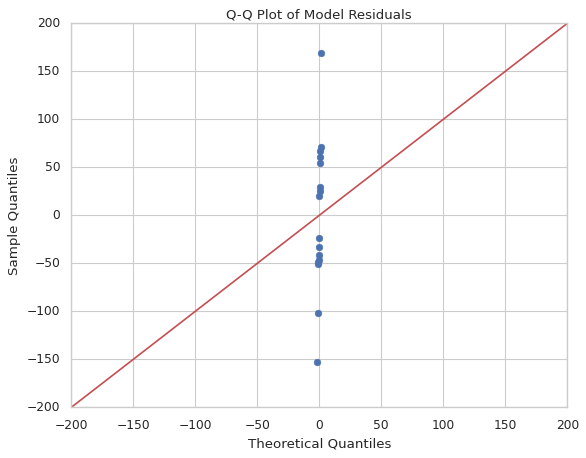

Shapiro-Wilk Test Statistic: 0.9685567407780465
p-value: 0.8147214811761188


In [20]:
## Question 8 Code ##
## First, import ols function ##
from statsmodels.formula.api import ols
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

## Fit the Model ##

sales_burritos_mod = ols('Sales ~ Location + Timing + Marketing', data=sales_burritos).fit()

## Extract Model Residuals ##

residuals = sales_burritos_mod.resid

## Use statsmodels to plot qqplot ##

sm.qqplot(residuals, line ='45')
plt.title('Q-Q Plot of Model Residuals')
plt.show()

## Run Shapiro-Wilk Test for Normality ##

shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test Statistic: {shapiro_test.statistic}')
print(f'p-value: {shapiro_test.pvalue}')



9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

**Answer:**

For constant variance:

 - None of our points overpass our threshold of |3|.
 - The points appear randomly scattered around the horizontal line at 0.
 - The B-P test p-value is greater than 0.05, suggesting that the constant variance assumption is met.
 - **Fail to reject the null hypothesis**

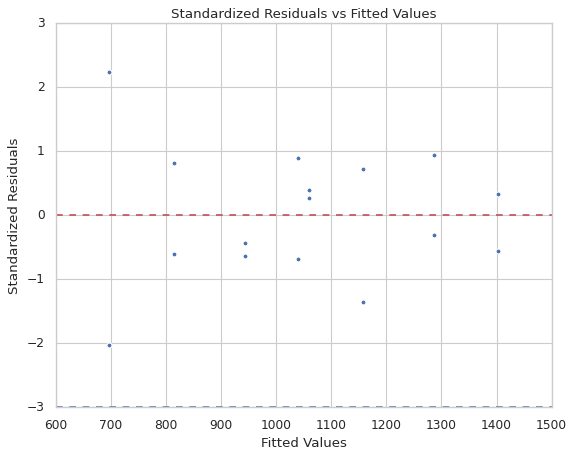

F-statistic: 3.261918353824198
F p-value: 0.05939124011896124


In [22]:
## Question 9 Code ##
## Generate Scatterplot of Standardized Residuals vs Fitted Values ##

standard_res = sales_burritos_mod.get_influence().resid_studentized_internal
fitted_vals = sales_burritos_mod.fittedvalues

plt.scatter(fitted_vals, standard_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=3, color='b', linestyle='--')
plt.axhline(y=-3, color='b', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Standardized Residuals')
plt.title('Standardized Residuals vs Fitted Values')
plt.show()

## Perform Breusch-Pagan Test for Homoscedasticity ##

bp_test = het_breuschpagan(residuals, sales_burritos_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer:**

All our main effects are statistically significant at the $\alpha<0.05$ threshold!

In [23]:
## Question 10 Code ##
## Print the ANOVA table ##

print(sm.stats.anova_lm(sales_burritos_mod, typ=1))

             df         sum_sq        mean_sq          F    PR(>F)
Location    1.0   54816.856900   54816.856900   7.241570  0.019633
Timing      1.0  471948.390225  471948.390225  62.346647  0.000004
Marketing   1.0  242000.044225  242000.044225  31.969367  0.000107
Residual   12.0   90836.972950    7569.747746        NaN       NaN


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

**Answer:**

 a.  As Location goes from the - level of brewery to the + level of university, we expect an increase of 245.97 in sales.
  
  b.  As Timing goes from the - level of weekday to the + level of weekend, we expect an increase of 343.49 in sales.
  
  c.  As Display goes from the - level of independent to the + level of partnership, we expect an increase of 15.72 in sales.

At this moment the Timing effect is the most important factor.

In [29]:
## Question 11 Code ##
## Group the Data by the Effect column and pivot from long to wide ##

df = (sales_burritos.groupby("Effect", as_index=False)["Sales"].mean())

## Now we want to pivot the DataFrame from long to wide format
## so that each effect is a separate column ##

df = df.pivot_table(index=None, columns='Effect', values='Sales').reset_index(drop=True)

## Extract factor columns for easier use ##

a   = df['a']
b   = df['b']
c   = df['c']
abc = df['abc']

## Compute factor estimates ##

df2 = pd.DataFrame({
    "A": 0.5 * (a - b - c + abc),
    "B": 0.5 * (-a + b - c + abc),
    "C": 0.5 * (-a - b + c + abc)
})

print(df)
print(df2)

Effect       a        abc         b         c
0       993.52  1352.7325  1091.045  763.2725
          A         B      C
0  245.9675  343.4925  15.72


12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

**Answer:**

All the main effect are larger effects, but the most importan is Timing, followed by Marketing and at last is the Location.

For the percentage of explanation we can deduce which effects are more important and which effects are less important.

In [30]:
## Question 12 Code ##
## Calculate Partial Eta Squared for Each Factor ##

## Load pingouin ##

import pingouin as pg

## Fit ANOVA with pingouin ##

mod2 = pg.anova(data=sales_burritos, dv='Sales', between=['Location','Timing','Marketing'], detailed=True)

print(mod2[["Source","np2"]][:3])

      Source       np2
0   Location  0.396275
1     Timing  0.849650
2  Marketing  0.743441


13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

**Answer:**

The best sales strategy for the company should be opened more time during the weekend, invest their money in a good marketing campaign and finally look for the best location depending the previous effects.

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

**Answer:**

Adding more additional ecxperimental fractions or using higher-resolution designs, this allow us to avoid confunding between them.

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

**Answer:**

With this practice we can protect the analysis to be bias, confunding and misleading the interpretations.

3.  What is the most important thing you learned in this class?

**Answer:**

Study Design is important to structure our analysis in a way that we can answer the research questions, as well make our analyis trustworthy.